正在读取真实存有 100 个样本的数据...
✅ 成品图已保存到: /workspace/SURF-2026-me/outputs/my_final_comparison4.png


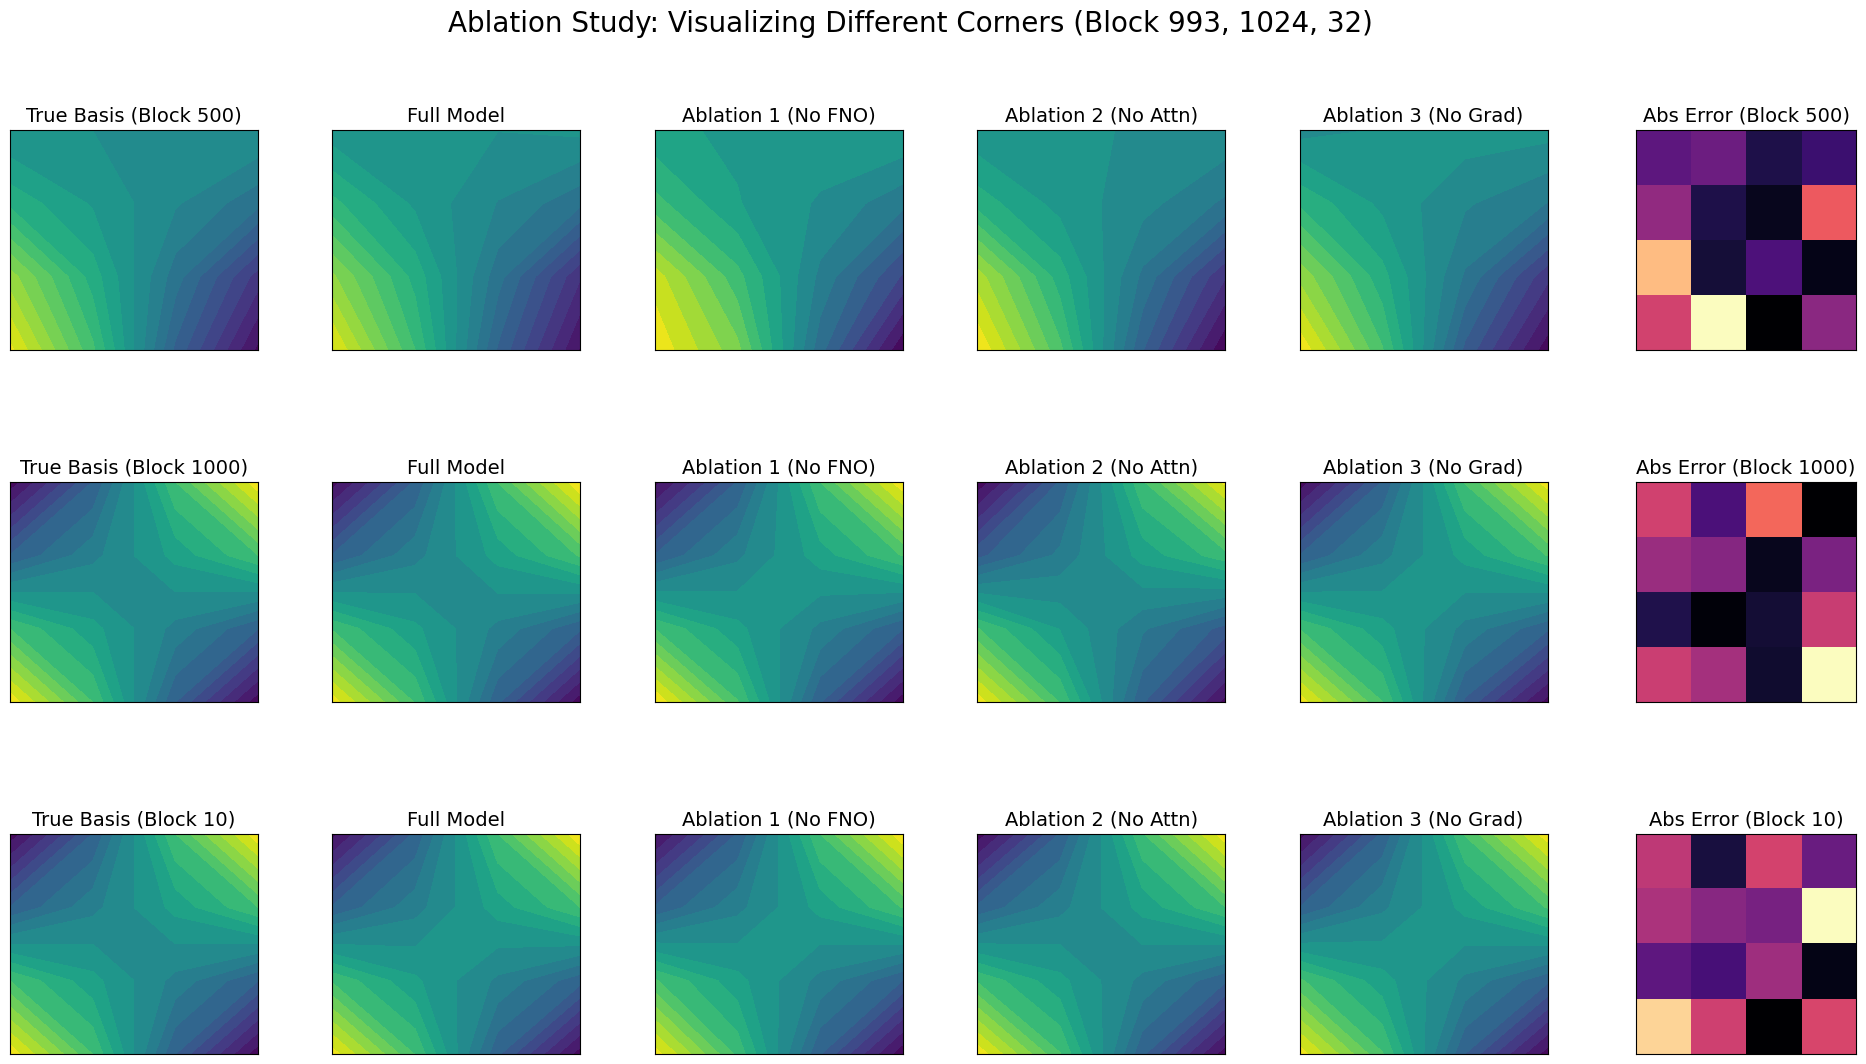

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

# ============================================================
# 👇 第一步：路径设置（保持不变）
# ============================================================
full_path = Path("/workspace/SURF-2026-me/outputs/teaching_single_basis/basis_04/predictions_basis_04.npz")
ab1_path = Path("/outputs/teaching_single_basis_no_fno/basis_04/predictions_basis_04.npz")
ab2_path = Path("/outputs/teaching_single_basis_no_attention/basis_04/predictions_basis_04.npz")
ab3_path = Path("/outputs/teaching_single_basis_no_gradient/basis_04/predictions_basis_04.npz")

print("正在读取真实存有 100 个样本的数据...")
y_true = np.load(full_path)['y_true']
y_full = np.load(full_path)['y_pred']
y_ab1 = np.load(ab1_path)['y_pred']
y_ab2 = np.load(ab2_path)['y_pred']
y_ab3 = np.load(ab3_path)['y_pred']

# ============================================================
# 👇 第二步：核心切块工具
# ============================================================
def coarse_element_patch(field, coarse_elem_idx, local_shape=(4, 4), one_based=True):
    arr = field.reshape(32, 32, 4, 4) 
    if one_based:
        idx = coarse_elem_idx - 1
    else:
        idx = coarse_elem_idx
    row = idx // 32
    col = idx % 32
    return arr[row, col]

# ============================================================
# 👇 第三步：差异化设计（【重点修改在这里】）
# ============================================================
# 1. 强行挑 3 个排序差距很大的样本（比如第 0 个、第 50 个、第 99 个）
sample_idx = [0, 50, 99]

# 2. 让这 3 行分别展示截然不同的粗网格区域 (左下、右下、左上)
# 第 1 行展示左下角 (Row=31, Col=0 -> Block 993)
# 第 2 行展示右下角 (Row=31, Col=31 -> Block 1024)
# 第 3 行展示右上角 (Row=0, Col=31 -> Block 32)
blocks_to_show = [500, 1000, 10]

# ============================================================
# 👇 第四步：超清画图
# ============================================================
fig, axes = plt.subplots(nrows=3, ncols=6, figsize=(24, 12))
plt.subplots_adjust(wspace=0.3, hspace=0.6)

def draw_contour(ax, data, title, block_idx):
    patch = coarse_element_patch(data, coarse_elem_idx=block_idx)
    contour = ax.contourf(patch, levels=20, cmap='viridis')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=14)

# 开始循环画图
for row in range(3):
    # 取第 row 行的样本索引和块索引
    i = sample_idx[row]
    current_block = blocks_to_show[row]
    
    # 列 1：真值
    draw_contour(axes[row, 0], y_true[i], f"True Basis (Block {current_block})", current_block)
    # 列 2：完整模型
    draw_contour(axes[row, 1], y_full[i], "Full Model", current_block)
    # 列 3：消融1
    draw_contour(axes[row, 2], y_ab1[i], "Ablation 1 (No FNO)", current_block)
    # 列 4：消融2
    draw_contour(axes[row, 3], y_ab2[i], "Ablation 2 (No Attn)", current_block)
    # 列 5：消融3
    draw_contour(axes[row, 4], y_ab3[i], "Ablation 3 (No Grad)", current_block)
    
    # 列 6：误差图
    error = np.abs(y_full[i] - y_true[i])
    patch_error = coarse_element_patch(error, coarse_elem_idx=current_block)
    axes[row, 5].imshow(patch_error, cmap='magma')
    axes[row, 5].set_xticks([])
    axes[row, 5].set_yticks([])
    axes[row, 5].set_title(f"Abs Error (Block {current_block})", fontsize=14)

fig.suptitle("Ablation Study: Visualizing Different Corners (Block 993, 1024, 32)", fontsize=20)

# 以 600 DPI 的超高分辨率保存，确保论文级印刷质量
save_path = Path("/workspace/SURF-2026-me/outputs/my_final_comparison4.png")
plt.savefig(save_path, dpi=600, bbox_inches='tight')
print(f"✅ 成品图已保存到: {save_path}")
plt.show()